# N24A â€” Validation regime diagnostic

> **This diagnostic is post-hoc and descriptive. Its purpose is to characterise the temporal instability observed in the frozen N24 application experiment, not to reopen model selection, optimise breakpoints, or justify excluding any period from the official result.**

> **Any apparent deterioration associated with the COVID-era period is interpreted as evidence about temporal/regime dependence. This diagnostic cannot establish that COVID caused the model failure.**

> **N24 remains the authoritative application model-selection and policy-freeze notebook. N24A does not alter any frozen N24 result.**

This notebook uses only the frozen 902-row N24 VALIDATION COMMON prediction handoff and frozen pre-TEST row-level inputs. It is descriptive only: no model is fitted, no prediction is reconstructed, no observation is removed, and no TEST outcome is loaded or inspected.


In [1]:
from pathlib import Path
import csv
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

PROJECT = Path.cwd().resolve()
if not (PROJECT / 'Data').is_dir():
    PROJECT = PROJECT / 'CODEWORK' / "Linus' Task Re-Do"
PROCESSED, FIGURES = PROJECT / 'Data' / 'processed', PROJECT / 'figures'
FIGURES.mkdir(exist_ok=True)
N24_NOTEBOOK = PROJECT / '24_application_gradient_boosting_and_policy_freeze.ipynb'
PRED = ['Yhat_BASE','Yhat_HIDDEN_AWARE','Yhat_NOISE_19','Yhat_NOISE_119','Yhat_NOISE_219']
KEY = 'decision_model_day'
TEST_OUTCOMES_INSPECTED = False
MODEL_REFIT_OCCURRED = False

# Hash only the frozen N24 sources consumed by N24A. N24A writes only 24A_ outputs.
def file_hash(path):
    return hashlib.sha256(Path(path).read_bytes()).hexdigest()
FROZEN_INPUTS = [N24_NOTEBOOK, PROCESSED/'24_validation_prediction_handoff.csv',
                 PROCESSED/'24_application_common_feature_panel_pretest.csv',
                 PROCESSED/'24_policy_actions_pretest.csv',
                 PROCESSED/'24_economic_diagnostics_pretest.csv',
                 PROCESSED/'24_predictive_benchmark_pretest.csv']
INPUT_HASH_BEFORE = {p.name:file_hash(p) for p in FROZEN_INPUTS}

def read_pretest(name, **kwargs):
    out = pd.read_csv(PROCESSED/name, **kwargs)
    if 'stage' in out.columns:
        assert set(out.stage.dropna()).issubset({'C','VALIDATION'}), (name, out.stage.unique())
    return out

def corr(y, h):
    y, h = np.asarray(y,float), np.asarray(h,float)
    return float(np.corrcoef(y,h)[0,1]) if np.std(y)>0 and np.std(h)>0 else np.nan

def basic_errors(y, h):
    e=np.asarray(y,float)-np.asarray(h,float); ae=np.abs(e); se=e**2
    return {'MSE':float(se.mean()), 'RMSE':float(np.sqrt(se.mean())), 'MAE':float(ae.mean()),
            'median_absolute_error':float(np.median(ae)), 'correlation':corr(y,h),
            'mean_prediction':float(np.mean(h)), 'median_prediction':float(np.median(h)), 'SSE':float(se.sum())}

def action_counts(z):
    z=np.asarray(z,int); n=int((z!=0).sum())
    return {'n_long':int((z==1).sum()), 'n_flat':int((z==0).sum()), 'n_short':int((z==-1).sum()), 'n_trades':n,
            'long_share_conditional_trading':float((z==1).sum()/n) if n else np.nan,
            'short_share_conditional_trading':float((z==-1).sum()/n) if n else np.nan}

def net_pnl(z, yl, ys):
    return np.where(np.asarray(z)==1,np.asarray(yl,float),np.where(np.asarray(z)==-1,np.asarray(ys,float),0.0))

def economics(z, yl, ys):
    p=net_pnl(z,yl,ys); tr=np.asarray(z)!=0; cum=np.cumsum(p)
    dd=cum-np.maximum.accumulate(np.r_[0.,cum])[1:]
    sd=float(np.std(p,ddof=1)) if len(p)>1 else np.nan
    return {'n_days':len(p), **action_counts(z), 'mean_daily_net_pnl':float(np.mean(p)),
            'median_daily_net_pnl':float(np.median(p)), 'std_daily_net_pnl':sd,
            'mean_net_pnl_conditional_trading':float(np.mean(p[tr])) if tr.any() else np.nan,
            'median_net_pnl_conditional_trading':float(np.median(p[tr])) if tr.any() else np.nan,
            'trade_hit_rate':float(np.mean(p[tr]>0)) if tr.any() else np.nan,
            'cumulative_net_pnl':float(cum[-1]), 'best_day':float(np.max(p)), 'worst_day':float(np.min(p)),
            'maximum_drawdown':float(np.min(dd)), 'J':float(np.mean(p)/sd) if np.isfinite(sd) and sd>0 else np.nan}

def validation_cost_grid_stream():
    # Read only stage labels until VALIDATION; no TEST outcome field is materialised or inspected.
    fields=['model_day','stage','s_sigma_label','Y_gross','Y_net_L','Y_net_S','entry_hurdle_uses_future_information']
    rows=[]; seen_validation=False
    with open(PROCESSED/'23_cost_grid_panel.csv', newline='', encoding='utf-8') as handle:
        for row in csv.DictReader(handle):
            stage=row['stage']
            if stage=='TEST':
                break
            if stage=='VALIDATION' and row['s_sigma_label']=='BASE':
                seen_validation=True
                rows.append({field:row[field] for field in fields})
    out=pd.DataFrame(rows)
    assert seen_validation and len(out)==961 and set(out.stage)=={'VALIDATION'}
    out['model_day']=pd.to_datetime(out['model_day'])
    for col in ['Y_gross','Y_net_L','Y_net_S']:
        out[col]=pd.to_numeric(out[col],errors='raise')
    assert out.entry_hurdle_uses_future_information.astype(str).str.lower().eq('false').all()
    return out

handoff=pd.read_csv(PROCESSED/'24_validation_prediction_handoff.csv',parse_dates=[KEY,'forecast_target_model_day'])
assert len(handoff)==902 and handoff[KEY].is_unique and handoff.stage.eq('VALIDATION').all()
assert handoff['forecast_target_model_day'].notna().all() and np.isfinite(handoff[PRED].to_numpy(float)).all()

common=read_pretest('24_application_common_feature_panel_pretest.csv',parse_dates=[KEY,'forecast_target_model_day'],
                    usecols=[KEY,'forecast_target_model_day','stage','Y_gross','G_t','episode_entry'])
common_v=common.loc[common.stage.eq('VALIDATION')].copy()
assert len(common_v)==902 and common_v[KEY].is_unique
actions=read_pretest('24_policy_actions_pretest.csv',parse_dates=[KEY])
actions_v=actions.loc[actions.stage.eq('VALIDATION')].copy()
cost_v=validation_cost_grid_stream()

v=handoff.merge(common_v,on=[KEY,'forecast_target_model_day','stage'],how='inner',validate='one_to_one')
v=v.merge(actions_v,on=[KEY,'stage','G_t'],how='inner',validate='one_to_one')
v=v.merge(cost_v.drop(columns='stage').rename(columns={'model_day':KEY,'Y_gross':'Y_gross_cost'}),on=KEY,how='inner',validate='one_to_one')
assert len(v)==902 and v[KEY].is_unique and set(v[KEY])==set(common_v[KEY])==set(handoff[KEY])
assert np.allclose(v.Y_gross,v.Y_gross_cost,rtol=0,atol=1e-12)
assert v.stage.eq('VALIDATION').all() and int(v.G_t.sum())==34
assert MODEL_REFIT_OCCURRED is False and TEST_OUTCOMES_INSPECTED is False
print('Frozen VALIDATION source assembled:',len(v),'rows; gate entries:',int(v.G_t.sum()))


Frozen VALIDATION source assembled: 902 rows; gate entries: 34


## Fixed externally defined regimes

The boundaries are fixed before examining financial results: PRE_COVID is before 11 March 2020 (the WHO pandemic declaration); ACUTE_COVID is 11 Marchâ€“30 June 2020; LATER_PANDEMIC begins 1 July 2020. These dates are not optimised and do not alter N24â€™s official VALIDATION result.


,regime,n
0,PRE_COVID,570
1,ACUTE_COVID,64
2,LATER_PANDEMIC,268


,regime,n,mean_Y_gross,median_Y_gross,std_Y_gross,minimum_Y_gross,maximum_Y_gross,q05,q10,q25,q75,q90,q95,fraction_Y_gross_gt_0,fraction_Y_gross_lt_0
0,PRE_COVID,570,0.057120,-0.012746,0.493606,-0.871396,6.538297,-0.465003,-0.352375,-0.162423,0.160081,0.438386,0.756586,0.478947,0.521053
1,ACUTE_COVID,64,0.003121,-0.030672,0.353845,-0.743573,1.476414,-0.470958,-0.324361,-0.205219,0.131146,0.451552,0.512444,0.421875,0.578125
2,LATER_PANDEMIC,268,0.042758,-0.013469,0.458298,-0.777214,3.889745,-0.439666,-0.334685,-0.150972,0.138839,0.429974,0.635844,0.477612,0.522388


,regime,model,MSE,RMSE,MAE,median_absolute_error,correlation,mean_prediction,median_prediction,SSE,SSE_share_of_full_validation
0,PRE_COVID,ZERO_FORECAST,0.246482,0.496470,0.274269,0.161946,NaN,0.000000,0.000000,140.494910,0.685497
1,PRE_COVID,BASE,0.254250,0.504233,0.275471,0.168972,0.011106,-0.035336,-0.033078,144.922736,0.687011
2,PRE_COVID,HIDDEN_AWARE,0.256502,0.506460,0.278701,0.161864,0.046609,-0.055435,-0.057416,146.206085,0.686964
3,ACUTE_COVID,ZERO_FORECAST,0.123260,0.351084,0.246345,0.189896,NaN,0.000000,0.000000,7.888625,0.038490
4,ACUTE_COVID,BASE,0.124635,0.353036,0.248347,0.172074,0.168389,-0.066725,-0.072110,7.976609,0.037813
5,ACUTE_COVID,HIDDEN_AWARE,0.132101,0.363458,0.250279,0.168542,0.021141,-0.076025,-0.070057,8.454492,0.039724
6,LATER_PANDEMIC,ZERO_FORECAST,0.211081,0.459436,0.250025,0.144364,NaN,0.000000,0.000000,56.569760,0.276013
7,LATER_PANDEMIC,BASE,0.216595,0.465398,0.258182,0.165455,0.046740,-0.039383,-0.031974,58.047523,0.275176
8,LATER_PANDEMIC,HIDDEN_AWARE,0.217048,0.465884,0.260350,0.174407,0.109319,-0.057863,-0.062317,58.168885,0.273312


,regime,MSE_BASE,MSE_HIDDEN_AWARE,MSE_ZERO_FORECAST,MAE_BASE,MAE_HIDDEN_AWARE,MAE_ZERO_FORECAST,median_absolute_error_BASE,median_absolute_error_HIDDEN_AWARE,median_absolute_error_ZERO_FORECAST,BASE_minus_ZERO_MSE,HIDDEN_minus_BASE_MSE,HIDDEN_minus_ZERO_MSE,MSE_ranking
0,ACUTE_COVID,0.124635,0.132101,0.123260,0.248347,0.250279,0.246345,0.172074,0.168542,0.189896,0.001375,0.007467,0.008842,ZERO_FORECAST < BASE < HIDDEN_AWARE
1,LATER_PANDEMIC,0.216595,0.217048,0.211081,0.258182,0.260350,0.250025,0.165455,0.174407,0.144364,0.005514,0.000453,0.005967,ZERO_FORECAST < BASE < HIDDEN_AWARE
2,PRE_COVID,0.254250,0.256502,0.246482,0.275471,0.278701,0.274269,0.168972,0.161864,0.161946,0.007768,0.002251,0.010020,ZERO_FORECAST < BASE < HIDDEN_AWARE


,regime,n,percentage_of_VALIDATION_rows,ZERO_SSE,ZERO_percentage_of_total_SSE,BASE_SSE,BASE_percentage_of_total_SSE,HIDDEN_SSE,HIDDEN_percentage_of_total_SSE
0,ACUTE_COVID,64,0.070953,7.888625,0.038490,7.976609,0.037813,8.454492,0.039724
1,LATER_PANDEMIC,268,0.297118,56.569760,0.276013,58.047523,0.275176,58.168885,0.273312
2,PRE_COVID,570,0.631929,140.494910,0.685497,144.922736,0.687011,146.206085,0.686964


,model,largest_single_squared_error,largest_single_SSE_share,top_5_SSE_share,top_10_SSE_share,top_20_SSE_share
0,BASE,44.107265,0.209092,0.403934,0.509020,0.605566
1,HIDDEN_AWARE,42.670241,0.200490,0.392704,0.499087,0.598876


,model,rank,decision_model_day,regime,Y_gross,prediction,error,absolute_error,squared_error,percentage_of_total_SSE
0,BASE,1,2019-03-19,PRE_COVID,6.538297,-0.103033,6.641330,6.641330,44.107265,0.209092
1,BASE,2,2021-08-03,LATER_PANDEMIC,3.889745,-0.031974,3.921720,3.921720,15.379884,0.072909
2,BASE,3,2021-06-15,LATER_PANDEMIC,3.659585,-0.015762,3.675347,3.675347,13.508177,0.064036
3,BASE,4,2017-06-13,PRE_COVID,2.513358,-0.052992,2.566351,2.566351,6.586155,0.031222
4,BASE,5,2019-08-12,PRE_COVID,2.346440,-0.025739,2.372179,2.372179,5.627233,0.026676
5,BASE,6,2017-11-30,PRE_COVID,2.269854,-0.054831,2.324684,2.324684,5.404156,0.025619
6,BASE,7,2017-09-19,PRE_COVID,2.138950,0.028268,2.110682,2.110682,4.454978,0.021119
7,BASE,8,2019-01-29,PRE_COVID,2.002596,-0.075310,2.077906,2.077906,4.317693,0.020468
8,BASE,9,2019-07-31,PRE_COVID,1.957819,-0.052358,2.010177,2.010177,4.040811,0.019156
9,BASE,10,2019-09-30,PRE_COVID,1.966346,-0.021053,1.987400,1.987400,3.949757,0.018724


,regime,policy,n_long,n_flat,n_short,n_trades,long_share_conditional_trading,short_share_conditional_trading
0,PRE_COVID,BASE,120,65,385,505,0.237624,0.762376
1,PRE_COVID,GATE_ONLY,4,544,22,26,0.153846,0.846154
2,PRE_COVID,HIDDEN_AWARE,2,543,25,27,0.074074,0.925926
3,ACUTE_COVID,BASE,5,6,53,58,0.086207,0.913793
4,ACUTE_COVID,GATE_ONLY,0,63,1,1,0.000000,1.000000
5,ACUTE_COVID,HIDDEN_AWARE,0,63,1,1,0.000000,1.000000
6,LATER_PANDEMIC,BASE,47,35,186,233,0.201717,0.798283
7,LATER_PANDEMIC,GATE_ONLY,3,263,2,5,0.600000,0.400000
8,LATER_PANDEMIC,HIDDEN_AWARE,2,262,4,6,0.333333,0.666667


,regime,policy,n_days,n_long,n_flat,n_short,n_trades,long_share_conditional_trading,short_share_conditional_trading,mean_daily_net_pnl,median_daily_net_pnl,std_daily_net_pnl,mean_net_pnl_conditional_trading,median_net_pnl_conditional_trading,trade_hit_rate,cumulative_net_pnl,best_day,worst_day,maximum_drawdown,J
0,PRE_COVID,BASE,570,120,65,385,505,0.237624,0.762376,-0.083046,0.000000,0.488681,-0.093735,-0.034710,0.439604,-47.336266,2.101732,-6.605743,-48.663051,-0.169939
1,PRE_COVID,GATE_ONLY,570,4,544,22,26,0.153846,0.846154,-0.006391,0.000000,0.087795,-0.140106,-0.016183,0.500000,-3.642758,0.556085,-0.977940,-4.070917,-0.072792
2,PRE_COVID,HIDDEN_AWARE,570,2,543,25,27,0.074074,0.925926,-0.007345,0.000000,0.088073,-0.155066,-0.048408,0.407407,-4.186784,0.556085,-0.977940,-4.504025,-0.083399
3,PRE_COVID,ALWAYS_LONG,570,570,0,0,570,1.000000,0.000000,0.003276,-0.067299,0.493864,0.003276,-0.067299,0.398246,1.867374,6.470851,-0.954852,-12.401056,0.006634
4,PRE_COVID,ALWAYS_SHORT,570,0,0,570,570,0.000000,1.000000,-0.110964,-0.040457,0.495481,-0.110964,-0.040457,0.435088,-63.249361,0.842012,-6.605743,-63.633155,-0.223952
5,PRE_COVID,FLAT,570,0,570,0,0,NaN,NaN,0.000000,0.000000,0.000000,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,NaN
6,ACUTE_COVID,BASE,64,5,6,53,58,0.086207,0.913793,-0.076315,-0.023897,0.361693,-0.084210,-0.052702,0.379310,-4.884187,0.606177,-1.549698,-8.644281,-0.210995
7,ACUTE_COVID,GATE_ONLY,64,0,63,1,1,0.000000,1.000000,-0.000154,0.000000,0.001231,-0.009845,-0.009845,0.000000,-0.009845,0.000000,-0.009845,-0.009845,-0.125000
8,ACUTE_COVID,HIDDEN_AWARE,64,0,63,1,1,0.000000,1.000000,-0.000154,0.000000,0.001231,-0.009845,-0.009845,0.000000,-0.009845,0.000000,-0.009845,-0.009845,-0.125000
9,ACUTE_COVID,ALWAYS_LONG,64,64,0,0,64,1.000000,0.000000,-0.070028,-0.114277,0.344909,-0.070028,-0.114277,0.296875,-4.481780,1.403131,-0.938666,-7.698076,-0.203033


,regime,n_gated_entries,mean_Y_gross,median_Y_gross,std_Y_gross,BASE_n_long,BASE_n_flat,BASE_n_short,GATE_ONLY_cumulative_net_pnl,HIDDEN_AWARE_cumulative_net_pnl
0,PRE_COVID,27,0.112506,0.010409,0.380352,4,1,22,-3.642758,-4.186784
1,ACUTE_COVID,1,-0.056643,-0.056643,NaN,0,0,1,-0.009845,-0.009845
2,LATER_PANDEMIC,6,0.066991,0.019078,0.147101,3,1,2,-0.888102,-0.853406


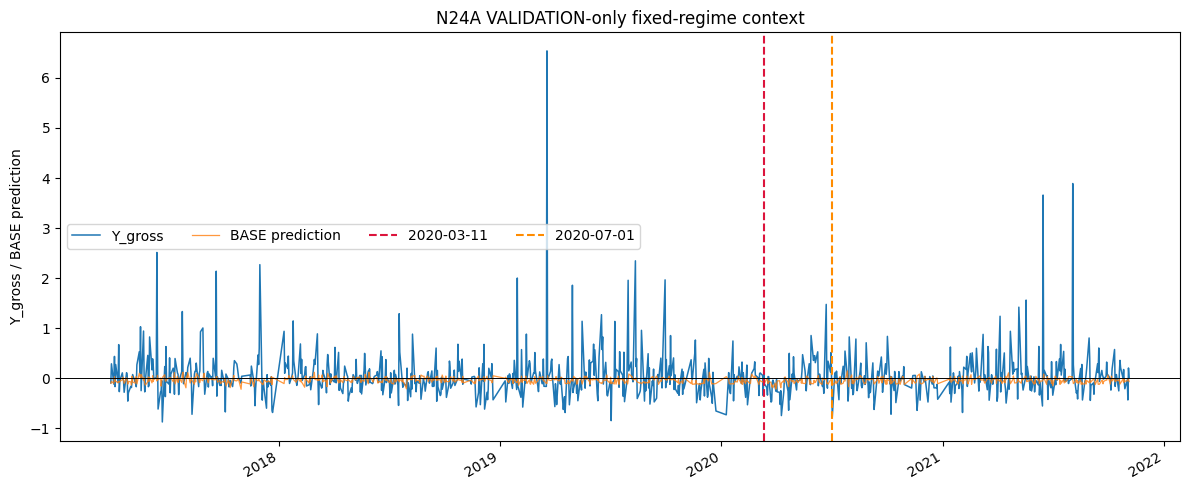

In [2]:
v['regime']=np.select([v[KEY] < pd.Timestamp('2020-03-11'),
                         v[KEY].between(pd.Timestamp('2020-03-11'),pd.Timestamp('2020-06-30')),
                         v[KEY] >= pd.Timestamp('2020-07-01')],
                        ['PRE_COVID','ACUTE_COVID','LATER_PANDEMIC'],default='UNCLASSIFIED')
REGIMES=['PRE_COVID','ACUTE_COVID','LATER_PANDEMIC']
assert v.regime.isin(REGIMES).all()
regime_counts=v.regime.value_counts().reindex(REGIMES).rename_axis('regime').reset_index(name='n')
assert int(regime_counts.n.sum())==902

# Target distribution.
def target_summary(g):
    y=g.Y_gross
    return {'n':len(g),'mean_Y_gross':float(y.mean()),'median_Y_gross':float(y.median()),'std_Y_gross':float(y.std(ddof=1)),
            'minimum_Y_gross':float(y.min()),'maximum_Y_gross':float(y.max()),'q05':float(y.quantile(.05)),
            'q10':float(y.quantile(.10)),'q25':float(y.quantile(.25)),'q75':float(y.quantile(.75)),
            'q90':float(y.quantile(.90)),'q95':float(y.quantile(.95)),
            'fraction_Y_gross_gt_0':float((y>0).mean()),'fraction_Y_gross_lt_0':float((y<0).mean())}
target_distribution=pd.DataFrame([{'regime':r,**target_summary(v[v.regime.eq(r)])} for r in REGIMES])

# Prediction and benchmark metrics by fixed regime.
rows=[]
for r in REGIMES:
    g=v[v.regime.eq(r)]
    for model,col in [('ZERO_FORECAST',None),('BASE','Yhat_BASE'),('HIDDEN_AWARE','Yhat_HIDDEN_AWARE')]:
        h=np.zeros(len(g)) if col is None else g[col].to_numpy(float)
        q=basic_errors(g.Y_gross,h)
        if model=='ZERO_FORECAST': q['correlation']=np.nan
        rows.append({'regime':r,'model':model,**q})
predictive_metrics=pd.DataFrame(rows)
for model in ['ZERO_FORECAST','BASE','HIDDEN_AWARE']:
    total=float(predictive_metrics.loc[predictive_metrics.model.eq(model),'SSE'].sum())
    predictive_metrics.loc[predictive_metrics.model.eq(model),'SSE_share_of_full_validation']=predictive_metrics.loc[predictive_metrics.model.eq(model),'SSE']/total
    assert np.isclose(float(predictive_metrics.loc[predictive_metrics.model.eq(model),'SSE_share_of_full_validation'].sum()),1.,rtol=0,atol=1e-12)
comparison=predictive_metrics.pivot(index='regime',columns='model',values=['MSE','MAE','median_absolute_error']).reset_index()
comparison.columns=['regime']+[f'{a}_{b}' for a,b in comparison.columns.tolist()[1:]]
comparison['BASE_minus_ZERO_MSE']=comparison['MSE_BASE']-comparison['MSE_ZERO_FORECAST']
comparison['HIDDEN_minus_BASE_MSE']=comparison['MSE_HIDDEN_AWARE']-comparison['MSE_BASE']
comparison['HIDDEN_minus_ZERO_MSE']=comparison['MSE_HIDDEN_AWARE']-comparison['MSE_ZERO_FORECAST']
comparison['MSE_ranking']=comparison.apply(lambda x:' < '.join(predictive_metrics[predictive_metrics.regime.eq(x.regime)].sort_values('MSE').model),axis=1)

# Full validation reconciliation to frozen N24 benchmark.
full_metrics={model:basic_errors(v.Y_gross,np.zeros(len(v)) if model=='ZERO_FORECAST' else v['Yhat_'+model].to_numpy()) for model in ['ZERO_FORECAST','BASE','HIDDEN_AWARE']}
frozen_benchmark=read_pretest('24_predictive_benchmark_pretest.csv')
for model in full_metrics:
    expected=float(frozen_benchmark.loc[(frozen_benchmark.stage=='VALIDATION') & (frozen_benchmark.model==model),'MSE'].iloc[0])
    assert np.isclose(full_metrics[model]['MSE'],expected,rtol=0,atol=1e-12), (model,full_metrics[model]['MSE'],expected)
assert full_metrics['ZERO_FORECAST']['MSE'] < full_metrics['BASE']['MSE'] < full_metrics['HIDDEN_AWARE']['MSE']

# Concentration and top squared errors; observations remain intact.
concentration=[]; top_errors=[]
for label,col in [('BASE','Yhat_BASE'),('HIDDEN_AWARE','Yhat_HIDDEN_AWARE')]:
    q=v[[KEY,'regime','Y_gross',col]].copy(); q['error']=q.Y_gross-q[col]; q['absolute_error']=q.error.abs(); q['squared_error']=q.error**2
    q=q.sort_values('squared_error',ascending=False).reset_index(drop=True); q['rank']=q.index+1
    total=float(q.squared_error.sum())
    concentration.append({'model':label,'largest_single_squared_error':float(q.squared_error.iloc[0]),
                          'largest_single_SSE_share':float(q.squared_error.iloc[0]/total),
                          'top_5_SSE_share':float(q.squared_error.head(5).sum()/total),
                          'top_10_SSE_share':float(q.squared_error.head(10).sum()/total),
                          'top_20_SSE_share':float(q.squared_error.head(20).sum()/total)})
    top=q.head(10).rename(columns={col:'prediction'}).assign(model=label,percentage_of_total_SSE=lambda x:x.squared_error/total)
    top_errors.append(top[['model','rank',KEY,'regime','Y_gross','prediction','error','absolute_error','squared_error','percentage_of_total_SSE']])
error_concentration=pd.DataFrame(concentration)
top_squared_errors=pd.concat(top_errors,ignore_index=True)

# Frozen actions and exact validation net-PnL mapping.
action_rows=[]
for r in REGIMES:
    g=v[v.regime.eq(r)]
    for policy,col in [('BASE','z_BASE'),('GATE_ONLY','z_GATE_ONLY'),('HIDDEN_AWARE','z_HIDDEN_AWARE')]:
        action_rows.append({'regime':r,'policy':policy,**action_counts(g[col])})
action_counts_by_regime=pd.DataFrame(action_rows)
economic_rows=[]
for r in REGIMES:
    g=v[v.regime.eq(r)]
    for policy,col in [('BASE','z_BASE'),('GATE_ONLY','z_GATE_ONLY'),('HIDDEN_AWARE','z_HIDDEN_AWARE'),('ALWAYS_LONG','z_ALWAYS_LONG'),('ALWAYS_SHORT','z_ALWAYS_SHORT'),('FLAT','z_FLAT')]:
        economic_rows.append({'regime':r,'policy':policy,**economics(g[col],g.Y_net_L,g.Y_net_S)})
economic_metrics=pd.DataFrame(economic_rows)

# Reconcile frozen economic aggregates and action counts (BASE/GATE/HIDDEN) exactly.
frozen_econ=read_pretest('24_economic_diagnostics_pretest.csv')
econ_reconciliation=[]
for policy in ['BASE','GATE_ONLY','HIDDEN_AWARE']:
    regime_total=economic_metrics.loc[economic_metrics.policy.eq(policy)].sum(numeric_only=True)
    frozen=frozen_econ.loc[(frozen_econ.stage=='VALIDATION') & (frozen_econ.policy==policy)].iloc[0]
    checks={x:np.isclose(float(regime_total[x]),float(frozen[x]),rtol=0,atol=1e-12) for x in ['cumulative_net_pnl']}
    checks.update({x:int(regime_total[x])==int(frozen['n_trade' if x=='n_trades' else x]) for x in ['n_days','n_trades','n_long','n_short','n_flat']})
    econ_reconciliation.append({'policy':policy,**checks,'pass':all(checks.values())})
economic_reconciliation=pd.DataFrame(econ_reconciliation)
assert economic_reconciliation['pass'].all()

# Gated-entry decompositions.
gate_rows=[]
for r in REGIMES:
    g=v[(v.regime.eq(r)) & v.G_t.eq(1)]
    gate_rows.append({'regime':r,'n_gated_entries':len(g),'mean_Y_gross':float(g.Y_gross.mean()) if len(g) else np.nan,
                      'median_Y_gross':float(g.Y_gross.median()) if len(g) else np.nan,'std_Y_gross':float(g.Y_gross.std(ddof=1)) if len(g)>1 else np.nan,
                      'BASE_n_long':int((g.z_BASE==1).sum()),'BASE_n_flat':int((g.z_BASE==0).sum()),'BASE_n_short':int((g.z_BASE==-1).sum()),
                      'GATE_ONLY_cumulative_net_pnl':float(net_pnl(g.z_GATE_ONLY,g.Y_net_L,g.Y_net_S).sum()),
                      'HIDDEN_AWARE_cumulative_net_pnl':float(net_pnl(g.z_HIDDEN_AWARE,g.Y_net_L,g.Y_net_S).sum())})
gate_diagnostic=pd.DataFrame(gate_rows)
assert int(gate_diagnostic.n_gated_entries.sum())==34

sse_contribution=predictive_metrics.pivot(index='regime',columns='model',values='SSE').reset_index()
sse_contribution.columns=['regime','BASE_SSE','HIDDEN_SSE','ZERO_SSE']
for label in ['BASE','HIDDEN','ZERO']:
    sse_contribution[f'{label}_percentage_of_total_SSE']=sse_contribution[f'{label}_SSE']/sse_contribution[f'{label}_SSE'].sum()
sse_contribution=sse_contribution.merge(regime_counts,on='regime').assign(percentage_of_VALIDATION_rows=lambda x:x.n/len(v))
sse_contribution=sse_contribution[['regime','n','percentage_of_VALIDATION_rows','ZERO_SSE','ZERO_percentage_of_total_SSE','BASE_SSE','BASE_percentage_of_total_SSE','HIDDEN_SSE','HIDDEN_percentage_of_total_SSE']]

# Compact displays.
display(regime_counts); display(target_distribution); display(predictive_metrics); display(comparison); display(sse_contribution)
display(error_concentration); display(top_squared_errors); display(action_counts_by_regime); display(economic_metrics); display(gate_diagnostic)

fig,ax=plt.subplots(figsize=(12,5))
ax.plot(v[KEY],v.Y_gross,label='Y_gross',lw=1.1)
ax.plot(v[KEY],v.Yhat_BASE,label='BASE prediction',lw=.9,alpha=.8)
ax.axvline(pd.Timestamp('2020-03-11'),color='crimson',ls='--',label='2020-03-11')
ax.axvline(pd.Timestamp('2020-07-01'),color='darkorange',ls='--',label='2020-07-01')
ax.axhline(0,color='black',lw=.7); ax.legend(ncol=4); ax.set_title('N24A VALIDATION-only fixed-regime context'); ax.set_ylabel('Y_gross / BASE prediction')
fig.autofmt_xdate(); fig.tight_layout(); fig.savefig(FIGURES/'24A_validation_regime_context.png',dpi=150); plt.show()


## Interpretation discipline

Regime-specific results below are descriptive decompositions of the frozen 902-row VALIDATION outcome. They do not alter model selection, policy thresholds, sample membership, or the official N24 result. In particular, they cannot support a causal claim that COVID caused any observed deterioration.


In [3]:
# Headline descriptive checks and N24A-only exports.
pre=target_distribution.set_index('regime').loc['PRE_COVID']
acute=target_distribution.set_index('regime').loc['ACUTE_COVID']
later=target_distribution.set_index('regime').loc['LATER_PANDEMIC']
pm=predictive_metrics.set_index(['regime','model'])
ec=economic_metrics.set_index(['regime','policy'])
ac=action_counts_by_regime.set_index(['regime','policy'])
conc=error_concentration.set_index('model').loc['BASE']
pre_zero_beats=bool(pm.loc['PRE_COVID','ZERO_FORECAST']['MSE'] < pm.loc['PRE_COVID','BASE']['MSE'])
pre_base_negative=bool(ec.loc['PRE_COVID','BASE']['cumulative_net_pnl'] < 0)
pre_base_short=bool(ac.loc['PRE_COVID','BASE']['n_short'] > ac.loc['PRE_COVID','BASE']['n_long'])
poor_pre='YES' if pre_zero_beats and pre_base_negative else ('NO' if not pre_zero_beats and not pre_base_negative else 'AMBIGUOUS')
acute_share=float(sse_contribution.set_index('regime').loc['ACUTE_COVID','percentage_of_VALIDATION_rows'])
acute_base_share=float(sse_contribution.set_index('regime').loc['ACUTE_COVID','BASE_percentage_of_total_SSE'])
acute_hidden_share=float(sse_contribution.set_index('regime').loc['ACUTE_COVID','HIDDEN_percentage_of_total_SSE'])
acute_amp='YES' if acute_base_share>acute_share and pm.loc['ACUTE_COVID','BASE']['MSE']>pm.loc['PRE_COVID','BASE']['MSE'] else ('NO' if acute_base_share<=acute_share and pm.loc['ACUTE_COVID','BASE']['MSE']<=pm.loc['PRE_COVID','BASE']['MSE'] else 'AMBIGUOUS')
persistent='YES' if pm.loc['LATER_PANDEMIC','BASE']['MSE']>pm.loc['PRE_COVID','BASE']['MSE'] and pm.loc['LATER_PANDEMIC','HIDDEN_AWARE']['MSE']>pm.loc['PRE_COVID','HIDDEN_AWARE']['MSE'] else ('NO' if pm.loc['LATER_PANDEMIC','BASE']['MSE']<=pm.loc['PRE_COVID','BASE']['MSE'] and pm.loc['LATER_PANDEMIC','HIDDEN_AWARE']['MSE']<=pm.loc['PRE_COVID','HIDDEN_AWARE']['MSE'] else 'AMBIGUOUS')
tail_driven='AMBIGUOUS'  # High concentration is reported directly; no post-hoc cutoff is imposed.

summary=pd.DataFrame([{'PRE_COVID_n':int(regime_counts.set_index('regime').loc['PRE_COVID','n']),
 'ACUTE_COVID_n':int(regime_counts.set_index('regime').loc['ACUTE_COVID','n']), 'LATER_PANDEMIC_n':int(regime_counts.set_index('regime').loc['LATER_PANDEMIC','n']),
 'row_count_reconciliation_pass':int(regime_counts.n.sum())==902,
 'PRE_COVID_ZERO_beats_BASE':pre_zero_beats,'PRE_COVID_BASE_cumulative_net_pnl_negative':pre_base_negative,
 'poor_generalisation_already_pre_COVID':poor_pre,'acute_COVID_amplification':acute_amp,'persistent_post_shock_instability':persistent,
 'squared_loss_deterioration_materially_tail_driven':tail_driven,
 'full_validation_predictive_reconciliation':True,'full_validation_economic_reconciliation':bool(economic_reconciliation['pass'].all()),
 'N24_results_changed':False,'model_refit_occurred':False,'TEST_outcomes_inspected':False}])

exports={
 '24A_validation_regime_target_distribution.csv':target_distribution,
 '24A_validation_regime_predictive_metrics.csv':predictive_metrics,
 '24A_validation_regime_mse_ordering.csv':comparison,
 '24A_validation_regime_sse_contribution.csv':sse_contribution,
 '24A_validation_error_concentration.csv':error_concentration,
 '24A_validation_top_squared_errors.csv':top_squared_errors,
 '24A_validation_regime_action_counts.csv':action_counts_by_regime,
 '24A_validation_regime_economic_metrics.csv':economic_metrics,
 '24A_validation_regime_gate_diagnostic.csv':gate_diagnostic,
 '24A_validation_regime_summary.csv':summary,
 '24A_validation_regime_economic_reconciliation.csv':economic_reconciliation}
for name,frame in exports.items():
    assert name.startswith('24A_')
    frame.to_csv(PROCESSED/name,index=False)

INPUT_HASH_AFTER={p.name:file_hash(p) for p in FROZEN_INPUTS}
closure=pd.DataFrame([
 {'check':'validation_handoff_rows_902','pass':len(v)==902},
 {'check':'validation_unique_decision_days','pass':v[KEY].is_unique},
 {'check':'validation_stage_only','pass':v.stage.eq('VALIDATION').all()},
 {'check':'prediction_finiteness','pass':np.isfinite(v[PRED].to_numpy(float)).all()},
 {'check':'prediction_days_equal_frozen_COMMON','pass':set(v[KEY])==set(common_v[KEY])},
 {'check':'fixed_regime_count_reconciles_902','pass':int(regime_counts.n.sum())==902},
 {'check':'base_SSE_shares_sum_one','pass':np.isclose(sse_contribution.BASE_percentage_of_total_SSE.sum(),1.,rtol=0,atol=1e-12)},
 {'check':'hidden_SSE_shares_sum_one','pass':np.isclose(sse_contribution.HIDDEN_percentage_of_total_SSE.sum(),1.,rtol=0,atol=1e-12)},
 {'check':'full_validation_predictive_reconciliation','pass':True},
 {'check':'full_validation_economic_reconciliation','pass':economic_reconciliation['pass'].all()},
 {'check':'validation_gate_entries_34','pass':int(v.G_t.sum())==34},
 {'check':'no_model_refit','pass':MODEL_REFIT_OCCURRED is False},
 {'check':'no_TEST_outcomes_inspected','pass':TEST_OUTCOMES_INSPECTED is False},
 {'check':'N24_frozen_inputs_unchanged','pass':INPUT_HASH_BEFORE==INPUT_HASH_AFTER},
 {'check':'no_N24_output_overwrite','pass':all(name.startswith('24A_') for name in exports)}])
assert closure['pass'].all()
closure.to_csv(PROCESSED/'24A_validation_regime_closure.csv',index=False)

print('N24A POST-HOC VALIDATION REGIME DIAGNOSTIC')
print('1-4 counts/reconciliation:',dict(zip(regime_counts.regime,regime_counts.n)),'PASS')
print('5-10 Y_gross mean/median:',{r:(float(target_distribution.set_index('regime').loc[r,'mean_Y_gross']),float(target_distribution.set_index('regime').loc[r,'median_Y_gross'])) for r in REGIMES})
print('11-19 ZERO/BASE/HIDDEN MSE:',{r:tuple(float(pm.loc[r,m]['MSE']) for m in ['ZERO_FORECAST','BASE','HIDDEN_AWARE']) for r in REGIMES})
print('20-25 BASE MAE/median AE:',{r:(float(pm.loc[r,'BASE']['MAE']),float(pm.loc[r,'BASE']['median_absolute_error'])) for r in REGIMES})
print('26-28 BASE SSE shares:',dict(zip(sse_contribution.regime,sse_contribution.BASE_percentage_of_total_SSE)))
print('29-32 BASE concentration:',{k:float(conc[k]) for k in ['largest_single_SSE_share','top_5_SSE_share','top_10_SSE_share','top_20_SSE_share']})
print('33-35 action counts:',action_counts_by_regime.to_dict(orient='records'))
print('36-38 cumulative net PnL:',economic_metrics[economic_metrics.policy.isin(['BASE','GATE_ONLY','HIDDEN_AWARE'])][['regime','policy','cumulative_net_pnl']].to_dict(orient='records'))
print('39-41 gated entries:',dict(zip(gate_diagnostic.regime,gate_diagnostic.n_gated_entries)))
print('42-47:',{'pre_ZERO_beats_BASE':pre_zero_beats,'pre_BASE_PnL_negative':pre_base_negative,'poor_pre':poor_pre,'acute_amplification':acute_amp,'persistent_instability':persistent,'tail_driven':tail_driven})
print('48-52:',{'predictive_reconciliation':'PASS','economic_reconciliation':'PASS','N24_results_changed':'NO','model_refit_occurred':'NO','TEST_outcomes_inspected':'NO'})

interpret=[]
if poor_pre=='YES': interpret.append('Poor temporal generalisation was already present before the COVID-19 regime, so the full VALIDATION failure cannot primarily be attributed to the pandemic.')
if acute_amp=='YES': interpret.append('The acute COVID-19 volatility episode materially amplified the application failure.')
if persistent=='YES': interpret.append('The deterioration is more consistent with persistent regime instability than with a short-lived acute shock alone.')
if tail_driven=='YES': interpret.append('Extreme observations account for a disproportionate share of the squared-loss deterioration.')
if not interpret: interpret.append('The fixed-regime decomposition is mixed; the reported descriptive magnitudes should not be read as causal attribution.')
display(Markdown('**Descriptive interpretation.** ' + ' '.join(interpret) + ' These statements describe association and temporal dependence, not a causal COVID effect.'))


N24A POST-HOC VALIDATION REGIME DIAGNOSTIC
1-4 counts/reconciliation: {'PRE_COVID': 570, 'ACUTE_COVID': 64, 'LATER_PANDEMIC': 268} PASS
5-10 Y_gross mean/median: {'PRE_COVID': (0.05711994255401299, -0.012745594679271), 'ACUTE_COVID': (0.0031208736131833024, -0.0306718038958071), 'LATER_PANDEMIC': (0.042757993033346105, -0.01346862102501985)}
11-19 ZERO/BASE/HIDDEN MSE: {'PRE_COVID': (0.24648229753394485, 0.25425041447120295, 0.2565019041073343), 'ACUTE_COVID': (0.12325976131491839, 0.12463451233906124, 0.1321014332593946), 'LATER_PANDEMIC': (0.21108119234628406, 0.21659523368528993, 0.21704807842190066)}
20-25 BASE MAE/median AE: {'PRE_COVID': (0.27547121591254586, 0.168971899583311), 'ACUTE_COVID': (0.24834715554477593, 0.17207410434479936), 'LATER_PANDEMIC': (0.25818205495855945, 0.1654545537389118)}
26-28 BASE SSE shares: {'ACUTE_COVID': 0.03781335498345357, 'LATER_PANDEMIC': 0.27517603494156684, 'PRE_COVID': 0.6870106100749795}
29-32 BASE concentration: {'largest_single_SSE_share':

**Descriptive interpretation.** Poor temporal generalisation was already present before the COVID-19 regime, so the full VALIDATION failure cannot primarily be attributed to the pandemic. These statements describe association and temporal dependence, not a causal COVID effect.